## Proyecto empresa aliada: entregable 1


# ENTREGABLE 2 INICIA MAS ABAJO



In [3]:
import pandas as pd

#cargar archivos  XLSX y CSV
df_DIM_CALENDAR = pd.read_excel('DIM_CALENDAR.xlsx')
df_DIM_CATEGORY= pd.read_csv('DIM_CATEGORY.csv')
df_DIM_PRODUCT = pd.read_excel('DIM_PRODUCT.xlsx')
df_DIM_SEGMENT = pd.read_excel('DIM_SEGMENT.xlsx')
df_FACT_SALES = pd.read_csv('FACT_SALES.csv')

In [4]:
#confirmar que se cargaron correctamente con el metodo 

df_DIM_CALENDAR.info() # No se observa nada raro

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   WEEK         156 non-null    object        
 1   YEAR         156 non-null    int64         
 2   MONTH        156 non-null    int64         
 3   WEEK_NUMBER  156 non-null    int64         
 4   DATE         156 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 6.2+ KB


In [5]:
df_DIM_CATEGORY.info() # No se observa nada raro

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID_CATEGORY  5 non-null      int64 
 1   CATEGORY     5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes


In [6]:
df_DIM_PRODUCT.info()# hay algunas columnas con valores 499 debo validar eso

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   MANUFACTURER      505 non-null    object
 1   BRAND             505 non-null    object
 2   ITEM              503 non-null    object
 3   ITEM_DESCRIPTION  505 non-null    object
 4   CATEGORY          505 non-null    int64 
 5   FORMAT            505 non-null    object
 6   ATTR1             499 non-null    object
 7   ATTR2             505 non-null    object
 8   ATTR3             499 non-null    object
dtypes: int64(1), object(8)
memory usage: 35.6+ KB


In [7]:
df_DIM_SEGMENT.info() #ATTR3 tiene solo 52 en lugar de 53 valores

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CATEGORY  53 non-null     int64 
 1   ATTR1     53 non-null     object
 2   ATTR2     53 non-null     object
 3   ATTR3     52 non-null     object
 4   FORMAT    53 non-null     object
 5   SEGMENT   53 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.6+ KB


In [8]:
df_FACT_SALES.info() # No hay valores vacios

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  object 
 1   ITEM_CODE                    122002 non-null  object 
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  object 
dtypes: float64(3), object(3)
memory usage: 5.6+ MB


# -----------INICIO DE LIMPIEZA DE FILES --------------

In [10]:
# uso el metodo .head() para ver si algo resalta a simple vista
#Hay un error en "FABRIC TREATMENT and SANIT\r\n" debe decir "FABRIC TREATMENT and SANIT"
df_DIM_CATEGORY.head(5)

,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT\r\n
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


In [11]:
df_DIM_CATEGORY['CATEGORY'] = df_DIM_CATEGORY['CATEGORY'].str.strip()

In [12]:
df_DIM_PRODUCT.isna().sum()# Uso este metodo de .isna().sum() para buscar valores NaN 

MANUFACTURER        0
BRAND               0
ITEM                2
ITEM_DESCRIPTION    0
CATEGORY            0
FORMAT              0
ATTR1               6
ATTR2               0
ATTR3               6
dtype: int64

In [13]:
df_DIM_SEGMENT.isna().sum()

CATEGORY    0
ATTR1       0
ATTR2       0
ATTR3       1
FORMAT      0
SEGMENT     0
dtype: int64

In [14]:
df_DIM_PRODUCT['ATTR1'].value_counts(dropna=False) # use este metodo para validar los valores de cada columna y buscar NaN

#Asi puedo ver que no hay mezcla de mayusculas y minusculas o valores invalidos


ATTR1
CLORO          243
SAFE BLEACH    218
PRELAVADOR      27
SANITIZANTE     11
NaN              6
Name: count, dtype: int64

In [15]:
df_DIM_SEGMENT['ATTR3'] = df_DIM_SEGMENT['ATTR3'].fillna('NO DEFINIDO')# Cambio el valor NaN por 'NO DEFINIDO' para no dejar celdas vacias. 

In [16]:
df_DIM_SEGMENT['ATTR3'].isna().value_counts()

ATTR3
False    53
Name: count, dtype: int64

In [17]:
#Me parece poco eficiente buscar columna por columna asi que investigue como implemetar un FOR-
#para buscar toda la tabla usando los metodos que ya habia implementado

for col in df_DIM_PRODUCT.columns:
    print(f"\nValores únicos en '{col}':")
    print(df_DIM_PRODUCT[col].value_counts(dropna=False))
    print("-" * 50)


Valores únicos en 'MANUFACTURER':
MANUFACTURER
RECKITT                     128
INDS. ALEN                  127
CLOROX                       94
CHURCH & DWIGHT              31
JABONERA LA ESPUMA           27
DELTA PRONATURA              22
OTHERS FABRICANTE UNIF.      21
QUIMICA GONCAL               13
BLANQUEADORA MEXICANA         9
CLARASOL                      6
SC JOHNSON                    5
IBERIA                        5
P&G                           4
GRUPO AC MARCAS               3
INDS. H24                     3
FAB. DE JABON LA REINERA      2
LA CORONA                     2
WHITE MAGIC                   1
LA JAPONESA                   1
ARTIC WHITE                   1
Name: count, dtype: int64
--------------------------------------------------

Valores únicos en 'BRAND':
BRAND
CLORALEX                     115
VANISH                       103
CLOROX                        94
OXI CLEAN                     31
BANDERA                       25
DR.BECKMANN                   22
OTH

In [18]:
    #uso el mismo metodo para contar los NaN
for col in df_DIM_PRODUCT.columns:
        print(f"\nValores vacios en '{col}':")
        print(df_DIM_PRODUCT[col].isna().value_counts(dropna=False))
        print("-" * 50)


Valores vacios en 'MANUFACTURER':
MANUFACTURER
False    505
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'BRAND':
BRAND
False    505
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'ITEM':
ITEM
False    503
True       2
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'ITEM_DESCRIPTION':
ITEM_DESCRIPTION
False    505
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'CATEGORY':
CATEGORY
False    505
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'FORMAT':
FORMAT
False    505
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'ATTR1':
ATTR1
False    499
True       6
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'ATTR2':
ATTR2
False    505
Name: count, dtyp

In [19]:
#ITEM , ATTR1 y ATTR3 tienen valores vacios,los cambio a "NO DEFINIDO"
df_DIM_PRODUCT = df_DIM_PRODUCT.fillna('NO DEFINIDO')


In [20]:
for col in df_FACT_SALES.columns:
    print(f"\nValores únicos en '{col}':")
    print(df_FACT_SALES[col].value_counts(dropna=False))
    print("-" * 50)


Valores únicos en 'WEEK':
WEEK
07-22    1629
14-22    1625
10-22    1622
09-22    1620
16-22    1619
         ... 
23-23    1442
26-23    1434
28-23    1433
25-23    1430
27-23    1429
Name: count, Length: 80, dtype: int64
--------------------------------------------------

Valores únicos en 'ITEM_CODE':
ITEM_CODE
7501025405106       560
7501025405885       560
4008455425412       560
7501025401849       560
7501025401856       560
                   ... 
7501025441326BP2      2
0616533000525         2
7501025402211         2
0123456808218         2
7501058716446         2
Name: count, Length: 350, dtype: int64
--------------------------------------------------

Valores únicos en 'TOTAL_UNIT_SALES':
TOTAL_UNIT_SALES
0.001     3755
0.002     2084
0.003     1583
0.004     1247
0.005     1169
          ... 
25.333       1
11.879       1
3.796        1
63.840       1
21.152       1
Name: count, Length: 15197, dtype: int64
--------------------------------------------------

Valores únicos 

In [21]:


for col in df_FACT_SALES.columns:
        print(f"\nValores vacios en '{col}':")
        print(df_FACT_SALES[col].isna().value_counts(dropna=False))
        print("-" * 50)


Valores vacios en 'WEEK':
WEEK
False    122002
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'ITEM_CODE':
ITEM_CODE
False    122002
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'TOTAL_UNIT_SALES':
TOTAL_UNIT_SALES
False    122002
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'TOTAL_VALUE_SALES':
TOTAL_VALUE_SALES
False    122002
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'TOTAL_UNIT_AVG_WEEKLY_SALES':
TOTAL_UNIT_AVG_WEEKLY_SALES
False    122002
Name: count, dtype: int64
--------------------------------------------------

Valores vacios en 'REGION':
REGION
False    122002
Name: count, dtype: int64
--------------------------------------------------


# ------ Unir los DataFrames ------
### df_DIM_CALENDAR 
### df_DIM_CATEGORY
### df_DIM_PRODUCT
### df_DIM_SEGMENT
### df_FACT_SALES

Realiza uniones entre los DataFrames para consolidar la información. 
Por ejemplo, une la tabla de productos con las ventas, las categorías y los segmentos.

In [25]:
#df_DIM_PRODUCT y df_FACT_SALES---------------------------------------------

In [26]:
df_DIM_PRODUCT.head(5) # DERECHA*-*-*-*-*-*-*-*-*-**-*-*-*-*-*-*-*-*-*

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [27]:
df_DIM_PRODUCT['ITEM'].str.strip()

0         0000075000592
1         0000075000608
2         0000075000615
3         0000075000622
4         0000075000639
             ...       
500    7501058789778BP1
501       7501025412142
502         NO DEFINIDO
503         NO DEFINIDO
504    7502240948188BP1
Name: ITEM, Length: 505, dtype: object

In [28]:
df_FACT_SALES.head(1) #IZQUIERDA*-*-*-*-*-*-*-*-*-**-*-*-*-*-*-*-*-*-*

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.0,TOTAL AUTOS AREA 5


In [29]:
df_FACT_SALES['ITEM_CODE'].str.strip()

0         7501058792808BP2
1            7501058715883
2            7702626213774
3            7501058716422
4            7501058784353
                ...       
121997    7501058792778BP1
121998       7501058757630
121999       7501058753441
122000    7702626204208BP1
122001       7501058784346
Name: ITEM_CODE, Length: 122002, dtype: object

In [30]:
#juntando los 2 Dataframes usando como referencia el ITEM e ITEM_CODE, dejando incluso los que no son iguales
#Para ver si hay algo que pueda checar despues. Dejo el indicador para filtrar 
df_SALES_PRODUCT = pd.merge(df_DIM_PRODUCT, df_FACT_SALES, left_on='ITEM', right_on='ITEM_CODE', how='left',indicator = True) 
df_SALES_PRODUCT =df_SALES_PRODUCT.set_index('ITEM_DESCRIPTION')
df_SALES_PRODUCT.shape

(122157, 15)

In [31]:
df_SALES_PRODUCT.head(5) #NUEVO DATAFRAME CON VENTAS Y PRODUCTOS

,MANUFACTURER,BRAND,ITEM,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,_merge
ITEM_DESCRIPTION,,,,,,,,,,,,,,,
CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 0000075000592,INDS. ALEN,CLORALEX,0000075000592,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,45-22,0000075000592,0.034,0.142,8.500,TOTAL AUTOS SCANNING MEXICO,both
CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 0000075000592,INDS. ALEN,CLORALEX,0000075000592,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,48-22,0000075000592,0.002,0.009,1.000,TOTAL AUTOS SCANNING MEXICO,both
CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 0000075000592,INDS. ALEN,CLORALEX,0000075000592,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,03-22,0000075000592,0.432,1.956,14.400,TOTAL AUTOS SCANNING MEXICO,both
CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 0000075000592,INDS. ALEN,CLORALEX,0000075000592,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,05-22,0000075000592,0.233,0.779,11.095,TOTAL AUTOS SCANNING MEXICO,both
CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 0000075000592,INDS. ALEN,CLORALEX,0000075000592,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,09-22,0000075000592,0.055,0.251,5.500,TOTAL AUTOS SCANNING MEXICO,both


In [32]:
df_SALES_PRODUCT_NaN = df_SALES_PRODUCT[df_SALES_PRODUCT['_merge'] != 'both']
df_SALES_PRODUCT_NaN.shape
#Encontre lineas con informacion faltante 

(155, 15)

In [33]:
df_SALES_PRODUCT_NaN.head(1) 

,MANUFACTURER,BRAND,ITEM,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,_merge
ITEM_DESCRIPTION,,,,,,,,,,,,,,,
CLORALEX FANTASIA FLORAL BOT PLAST 950ML NAL 0000075000646,INDS. ALEN,CLORALEX,0000075000646,1,LIQUIDO,CLORO,CLORO,OTR. TIPOS,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [34]:
#No puedo hacer nada con estos productos. no veo caracteres de mas o espcios
#parece que solo son Items que no se vendieron entre las de las semanas de año registradas
df_SALES_PRODUCT_NaN['ITEM'].value_counts()

ITEM
NO DEFINIDO         2
7501058791658BP1    1
7501058789365       1
7501058790422BP1    1
7501058790705BP2    1
                   ..
7501025441319BP2    1
7501025441357BP1    1
7501025441463BP2    1
7501025450274       1
7501058757647       1
Name: count, Length: 154, dtype: int64

In [35]:
# Voy a dejar el DataFrame sin las lineas vacias. 

df_SALES_PRODUCT = pd.merge(df_DIM_PRODUCT, df_FACT_SALES, left_on='ITEM', right_on='ITEM_CODE', how='inner') 



df_SALES_PRODUCT.shape#NUEVO DATAFRAME CON VENTAS Y PRODUCTOS*-*-*-*-*-*-*-*-*-*

(122002, 15)

In [36]:
#df_DIM_CATEGORY y df_DIM_SEGMENT --------------------------------------------------------
#Pensaba unir Datafrmes usando el ID_CATEGORY, pero todos los archivosque hacen refererencia a categoria tienen "1". 
#Se asume que hay un error con el archivo ya que no puedo asumir la categoria sin mas informacion.
#Las columnas ATTR1, 2 y 3 estan en mi nuevo DataFrame de productos y ventas. los puedo usar para identificar el segmento.

In [37]:
df_DIM_CATEGORY.head(5)

,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


In [38]:
df_DIM_SEGMENT.head(20)

,CATEGORY,ATTR1,ATTR2,ATTR3,FORMAT,SEGMENT
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH
1,1,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH
2,1,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH
3,1,CLORO,CLORO,MULTIUSOS,GEL,BLEACH
4,1,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH
5,1,CLORO,CLORO,NO DEFINIDO,LIQUIDO,BLEACH
6,1,CLORO,CLORO,NO DEFINIDO,POLVO,BLEACH
7,1,CLORO,CLORO,OTR. TIPOS,LIQUIDO,BLEACH
8,1,CLORO,CLORO,OTR. TIPOS,POLVO,BLEACH
9,1,CLORO,CLORO,ROPA BEBE,LIQUIDO,BLEACH


In [39]:
#Unir Segmento con ventas y productos. 
df_SALES_PRODUCT_SEGMENT = pd.merge(df_SALES_PRODUCT, df_DIM_SEGMENT, on= ['ATTR1', 'ATTR2', 'ATTR3','FORMAT'], how='left')




df_SALES_PRODUCT_SEGMENT ['SEGMENT'].value_counts() #NUEVO DATA FRAME CON VENTAS, PRODUCTOS Y SEGMENTO

SEGMENT
BLEACH          83646
LIQUID & GEL    22697
PRETREAT        19143
POWDER          17694
SANITIZER        5023
BAR              3639
OTHERS            560
Name: count, dtype: int64

In [40]:
df_SALES_PRODUCT_SEGMENT.isna().any().sum() #checando que no tenga valores vacios

0

In [41]:
df_SALES_PRODUCT_SEGMENT.head(1)

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY_x,FORMAT,ATTR1,ATTR2,ATTR3,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,CATEGORY_y,SEGMENT
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,45-22,0000075000592,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,1,BLEACH


In [42]:
#df_DIM_CALENDAR con el DataFrame principal
#Voy a unir la informacion de la semana de los 2 dataframes
df_DIM_CALENDAR.head(1)

,WEEK,YEAR,MONTH,WEEK_NUMBER,DATE
0,01-21,2021,1,1,2021-01-10


In [43]:
df_SALES_PRODUCT_SEGMENT_DATE = pd.merge(df_SALES_PRODUCT_SEGMENT, df_DIM_CALENDAR, on= ['WEEK'], how='left')
df_SALES_PRODUCT_SEGMENT_DATE.isna().any().sum()

0

In [44]:
df_SALES_PRODUCT_SEGMENT_DATE.head(1)

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY_x,FORMAT,ATTR1,ATTR2,ATTR3,WEEK,...,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,CATEGORY_y,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO,45-22,...,0.034,0.142,8.5,TOTAL AUTOS SCANNING MEXICO,1,BLEACH,2022,11,45,2022-11-13


In [45]:
df_SALES_PRODUCT_SEGMENT_DATE.columns

Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY_x',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3', 'WEEK', 'ITEM_CODE',
       'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES',
       'REGION', 'CATEGORY_y', 'SEGMENT', 'YEAR', 'MONTH', 'WEEK_NUMBER',
       'DATE'],
      dtype='object')

# ------LIMPIAR DATAFRAME CONSOLIDADO ------

In [47]:
#Quitar columnas duplicadas o que no se usan
df_consolidado = df_SALES_PRODUCT_SEGMENT_DATE.drop(columns=['CATEGORY_y','ITEM_CODE','CATEGORY_x','WEEK'])

In [48]:
#Reorganizar DataFrame
column_consolidado = [
    'MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'FORMAT',
    'ATTR1', 'ATTR2', 'ATTR3','REGION', 'SEGMENT', 'YEAR', 'MONTH',
    'WEEK_NUMBER', 'DATE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
    'TOTAL_UNIT_AVG_WEEKLY_SALES'
]



In [49]:
df_consolidado = df_consolidado[column_consolidado]

In [50]:
#Cambiar index
df_consolidado = df_consolidado.set_index('ITEM')
df_consolidado["ITEM_DESCRIPTION"] = df_consolidado["ITEM_DESCRIPTION"].str.slice(stop=-13)


In [51]:
df_consolidado.head(50)

,MANUFACTURER,BRAND,ITEM_DESCRIPTION,FORMAT,ATTR1,ATTR2,ATTR3,REGION,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
ITEM,,,,,,,,,,,,,,,,
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,1,3,2022-01-23,0.432,1.956,14.400
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,1,3,2022-01-23,0.432,1.956,14.400
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,2,5,2022-02-06,0.233,0.779,11.095
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,2,5,2022-02-06,0.233,0.779,11.095
0000075000592,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL.,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,3,9,2022-03-06,0.055,0.251,5.500


# ----------------- ENTREGABLE 2 ------------------------------

## Resumen:
### Me parece que en esta actividad tuve problemas para identidicar que era realmente relevante para graficar y como encontrar coorelaciones entre columnas. Pero me parece que hay modulos que explican eso mas a detalle y el objetivo de esta actividad es demostrar que estoy comprendiendo como navegar e implementar matplotlib.pyplot y seaborn. 

### Ademas de tener problemas coorelacionando, me parece que se pueden optimizar mas los valores de algunas columnas para que sea mas facil su interpretacion,mas no me queda completamente claro como, me parece que es algo que ire aprendiendo mas con la practica. 

## Asignando valores a las categorias con base a sus atributos

In [55]:
df_consolidado.info() #revisando columnas


<class 'pandas.core.frame.DataFrame'>
Index: 152402 entries, 0000075000592 to 7502240948188BP1
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   MANUFACTURER                 152402 non-null  object        
 1   BRAND                        152402 non-null  object        
 2   ITEM_DESCRIPTION             152402 non-null  object        
 3   FORMAT                       152402 non-null  object        
 4   ATTR1                        152402 non-null  object        
 5   ATTR2                        152402 non-null  object        
 6   ATTR3                        152402 non-null  object        
 7   REGION                       152402 non-null  object        
 8   SEGMENT                      152402 non-null  object        
 9   YEAR                         152402 non-null  int64         
 10  MONTH                        152402 non-null  int64         
 11  WEEK_NUMB

In [56]:
#Quiero entender mejor como puedo asignar las categorias a este DF usando estos datos
df_consolidado[['FORMAT', 'SEGMENT','ATTR1','ATTR2','ATTR3']].value_counts()

FORMAT   SEGMENT       ATTR1        ATTR2             ATTR3      
LIQUIDO  BLEACH        CLORO        CLORO             NO DEFINIDO    60800
GEL      BLEACH        CLORO        CLORO             MULTIUSOS      13359
LIQUIDO  PRETREAT      SAFE BLEACH  FABRIC TREATMENT  PRE LAVADOR     9012
                       PRELAVADOR   FABRIC TREATMENT  PRE LAVADOR     9011
GEL      LIQUID & GEL  SAFE BLEACH  FABRIC TREATMENT  PRE LAVADOR     6945
POLVO    POWDER        SAFE BLEACH  FABRIC TREATMENT  ROSA            6175
LIQUIDO  LIQUID & GEL  SAFE BLEACH  FABRIC TREATMENT  BLANCO          5943
         BLEACH        CLORO        CLORO             MASCOTAS        5571
POLVO    POWDER        SAFE BLEACH  FABRIC TREATMENT  BLANCO          5540
                                                      PRE LAVADOR     5447
LIQUIDO  SANITIZER     SANITIZANTE  SANITIZANTE       SANITIZANTE     5023
         LIQUID & GEL  SAFE BLEACH  FABRIC TREATMENT  ROSA            3997
GEL      LIQUID & GEL  SAFE BLEACH

In [57]:
df_DIM_CATEGORY.head(5)

,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


In [58]:
#Usando este metodo busque un algunas combinaciones que me pudieran dar mas pistas de como asignar las categorias
df_consolidado[df_consolidado['BRAND'] == 'LYSOL'][['ATTR1','ATTR2','ATTR3','ITEM_DESCRIPTION','BRAND']].value_counts()


ATTR1        ATTR2        ATTR3        ITEM_DESCRIPTION                                                  BRAND
SANITIZANTE  SANITIZANTE  SANITIZANTE  LYSOL SANITIZANTE DE ROPA CRISP LINEN BOT 1.2 LT                  LYSOL    564
                                       LYSOL CRISP LINEN SANITIZANTE DE ROPA BOT 2.66 LT                 LYSOL    560
                                       LYSOL SANITIZANTE DE ROPA CRISP LINEN SCENT POUCH 500 ML          LYSOL    560
                                       LYSOL CRISP LINEN SANITIZANTE DE ROPA BOT 1 LT                    LYSOL    540
                                       LYSOL SANITIZANTE DE ROPA CRISP LINEN BOT 2 LT                    LYSOL    500
                                       LYSOL SANITIZANTE DE ROPA SPORT BOTELLA 1.21 LT                   LYSOL    479
                                       LYSOL LAUNDRYSANITIZERPOUCH500M+MMDESINFCRISPLINENLAT354GPVP 750  LYSOL    246
Name: count, dtype: int64

In [59]:
df_consolidado[df_consolidado["ATTR2"] == "CLORO"][['ATTR1','ATTR2','ATTR3','ITEM_DESCRIPTION']].value_counts()

ATTR1  ATTR2  ATTR3        ITEM_DESCRIPTION                                          
CLORO  CLORO  NO DEFINIDO  BLANCATEL CONCENTRADO BOT PLAST 3750ML NAL                    1970
                           CLORALEX AROMA CLORO LIQUIDO LAVANDA BP 2L                    1120
                           BLANCATEL LAVANDA LIQ BOT PLAST 3750ML NAL                    1120
                           CLARASOL BLANQUEADOR REGULAR BOT PLAST 1LT NAL                1120
                           BANDERA CLORHADA CONCENTRADO BOT. PLAS 2000 ML NAL            1120
                                                                                         ... 
              MULTIUSOS    HARPIC ULTRA CLORO GEL CITRUS BOT 650ML                          2
                           CLORALEX AROMAX FLORAL CLORO GEL CON DETERGENTE BOT 600ML        2
              NO DEFINIDO  CLOROX CONTROL BLEACH 12 PODS CLORO EN POLVO BOT 252GR           2
              ROPA BEBE    CLORALEX BAMBINO BOT PLAST 2000ML NAL    

In [60]:
#Me parece que puedo asignar la categoria MEGA SUPERFICIES a los atributos CLORO con ATTR3 NO DEFINIDO,FABRIC TREATMENT and SANIT a lo que diga FABRIC TREATMENT y SANITIZANTE en ATT2  y LAVATORY CARE & BRC a lo que diga MULTIUSOS en el ATT3.  
#No parece haber elementos que hagan mencion de AIR CARE o LAVAVAJILLAS exclusivamente en ninguna columna.

In [61]:
#Funcion para asignar Categorias
def newcat (Row): 
    if  (Row['ATTR1'] == 'CLORO') & (Row['ATTR3'] == 'NO DEFINIDO'):
        return 'MEGA SUPERFICIES'
    elif (Row['ATTR2'] == 'FABRIC TREATMENT') | (Row['ATTR2'] == 'SANITIZANTE'):
        return 'FABRIC TREATMENT and SANIT'
    else:
        return 'LAVATORY CARE & BRC'

In [62]:
df_consolidado['CATEGORIA'] = df_consolidado.apply(newcat, axis='columns')

In [63]:
df_consolidado.CATEGORIA.value_counts()

CATEGORIA
FABRIC TREATMENT and SANIT    68756
MEGA SUPERFICIES              64172
LAVATORY CARE & BRC           19474
Name: count, dtype: int64

## Inicio de Graficas

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt 

([0, 1, 2],
 [Text(0, 0, 'MEGA SUPERFICIES'),
  Text(1, 0, 'FABRIC TREATMENT and SANIT'),
  Text(2, 0, 'LAVATORY CARE & BRC')])

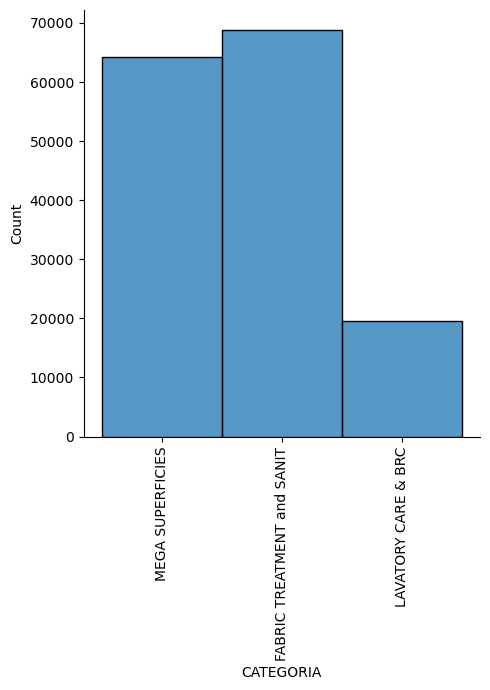

In [66]:
# Visualizando algunas columnas para analizar un poco mejor sus caracteristicas
sns.displot(df_consolidado.CATEGORIA )
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'BLEACH'),
  Text(1, 0, 'SANITIZER'),
  Text(2, 0, 'PRETREAT'),
  Text(3, 0, 'LIQUID & GEL'),
  Text(4, 0, 'POWDER'),
  Text(5, 0, 'OTHERS'),
  Text(6, 0, 'BAR')])

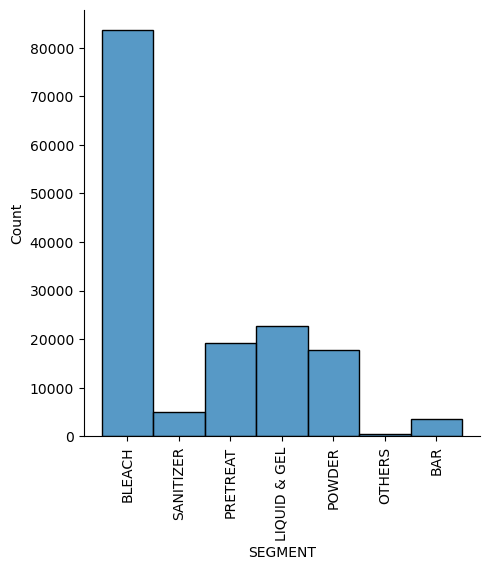

In [67]:

sns.displot(df_consolidado.SEGMENT )
plt.xticks(rotation=90)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'LIQUIDO'),
  Text(1, 0, 'POLVO'),
  Text(2, 0, 'GEL'),
  Text(3, 0, 'TOALLAS'),
  Text(4, 0, 'BARRA')])

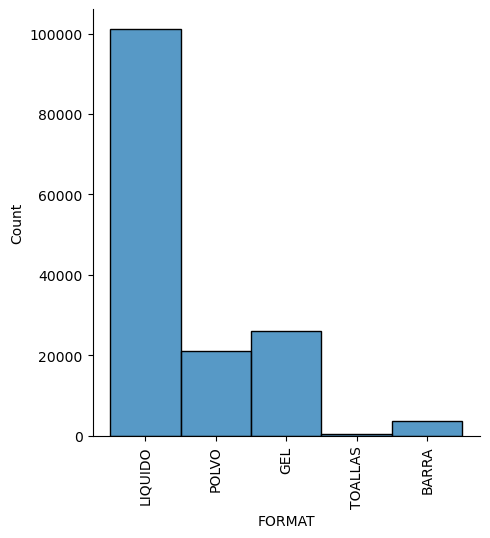

In [68]:
# Formato mas vendido
sns.displot(df_consolidado.FORMAT )
plt.xticks(rotation=90)



([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'TOTAL AUTOS SCANNING MEXICO'),
  Text(1, 0, 'TOTAL AUTOS AREA 1'),
  Text(2, 0, 'TOTAL AUTOS AREA 4'),
  Text(3, 0, 'TOTAL AUTOS AREA 6'),
  Text(4, 0, 'TOTAL AUTOS AREA 2'),
  Text(5, 0, 'TOTAL AUTOS AREA 5'),
  Text(6, 0, 'TOTAL AUTOS AREA 3')])

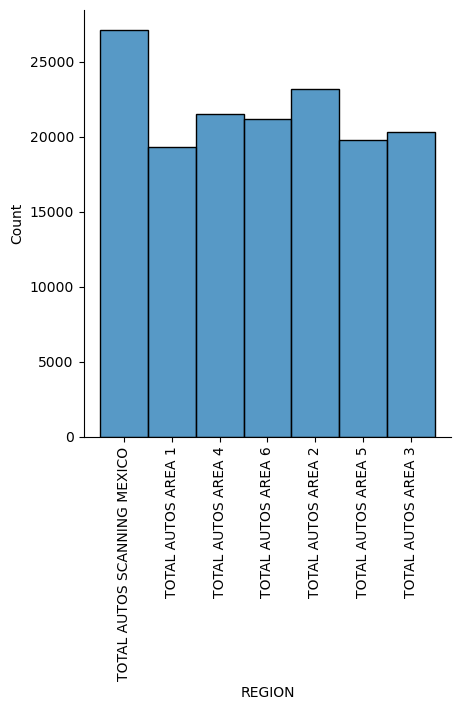

In [69]:

sns.displot(df_consolidado.REGION )
plt.xticks(rotation=90)

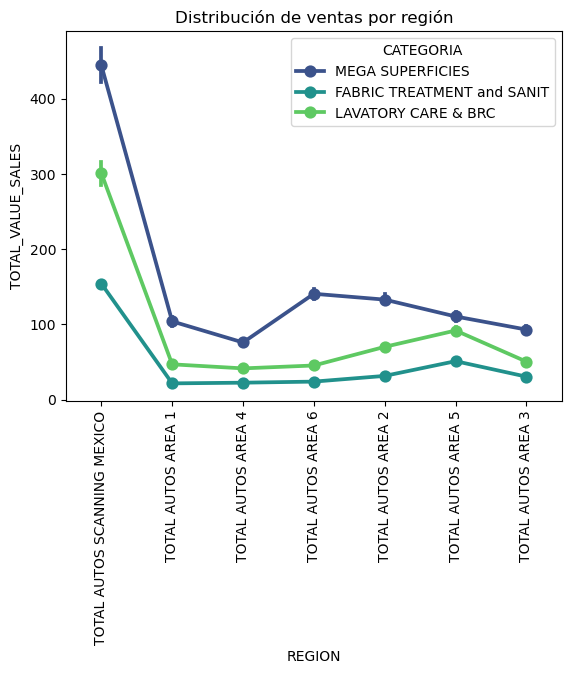

In [147]:
#Que quiero saber: Si alguna categoria se vende mas o menos en alguna region en particular.
#Esta infomacion puede ser importante para hacer campañas para productos que son mas debiles o para ajustar su distribucion a estas areas.

# Aqui se puede ver que en algunas regiones es mas popular algunas categorias de productos que en otras.
# No estoy seguro que es SCANNING MEXICO, pero parece ser un consolidado de todas las areas en Mexico.

sns.pointplot(data = df_consolidado, x='REGION' , y= 'TOTAL_VALUE_SALES', hue ='CATEGORIA' , palette="viridis" )
plt.title("Distribución de ventas por región")
plt.xticks(rotation=90)
plt.savefig('Distribución_ventas_región',dpi=90)



Text(0.5, 1.0, 'Distribución de ventas anuales por categoria.')

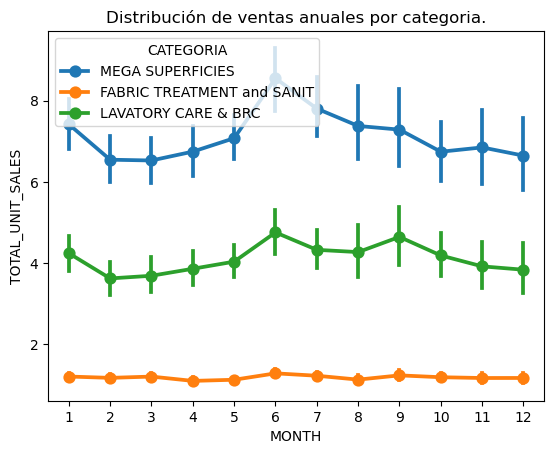

In [141]:
#Que quiero saber: Quiero saber si hay alguna temporada donde se vendan mas productos.
#Esto con el fin de ajustar la produccion y distribucion de a cuerdo a la demanda. 
#Tambien es relevante para preparar campañas de publicidad en esas fechas oen las mas debiles. 

# Parece que en el mes de Junio hay un pico en las ventas, quiza limpieza de verano?.
sns.pointplot(data = df_consolidado, x='MONTH' , y= 'TOTAL_UNIT_SALES', marker = 'o', hue= 'CATEGORIA')
plt.title("Distribución de ventas anuales por categoria.")
plt.savefig('Distribución_ventas_anuales_categoria',dpi=90)

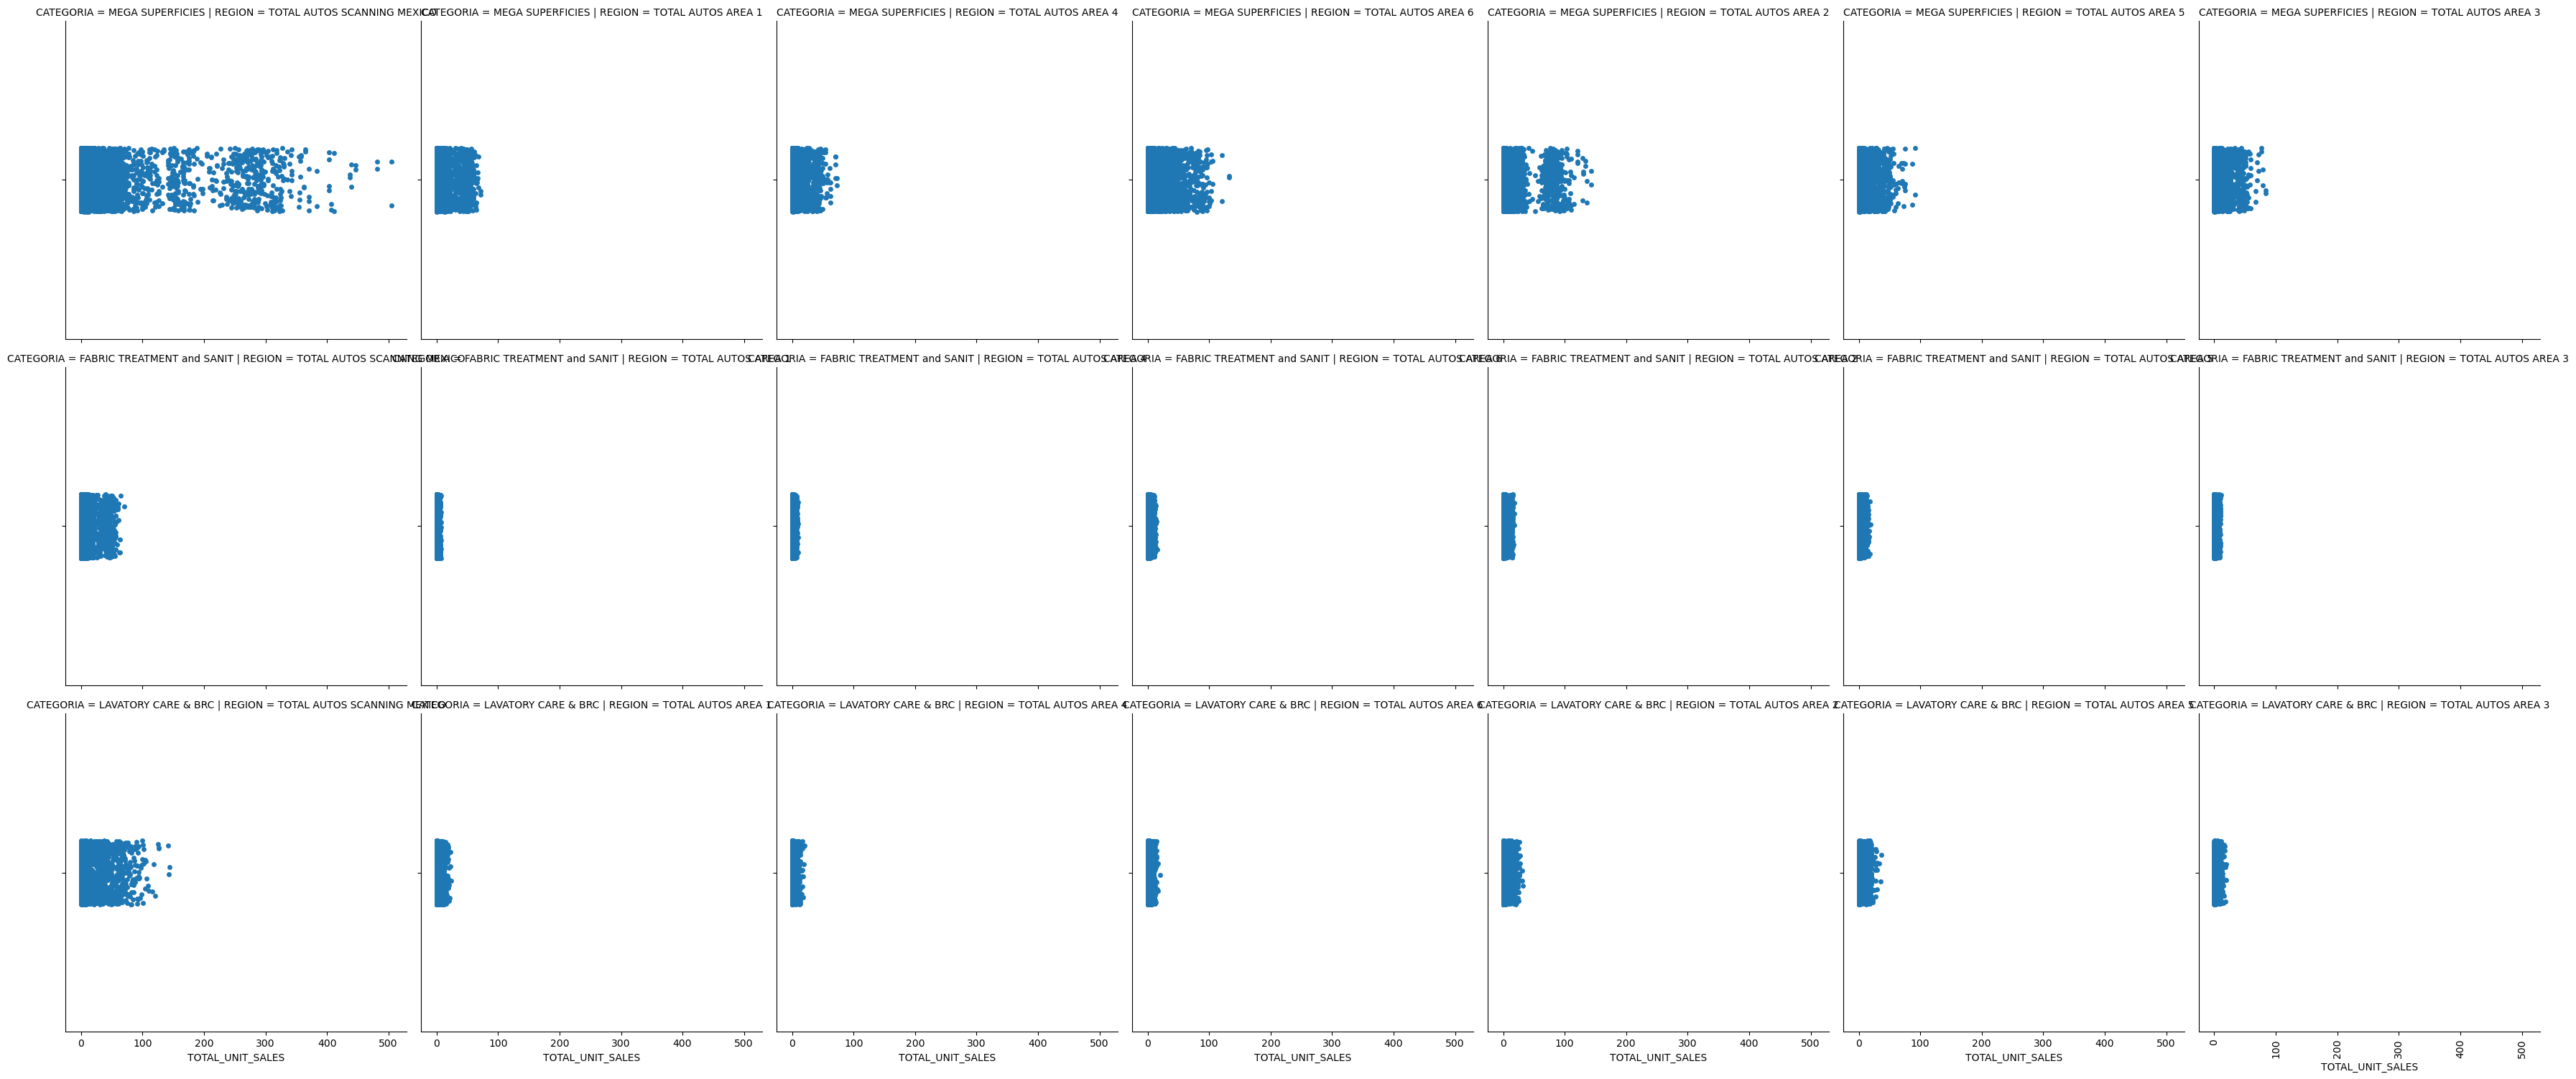

In [157]:
# Que quiero saber: Quiero ver si hay alguna grafica con algun resultado llamativo entre unidades vendidas, regiones y Categorias.
#Destaca pricipalmente la Categoria de de MEGA SUPERFICIES en SCANNING MEXICO. 

sns.catplot(data=df_consolidado, x="TOTAL_UNIT_SALES",col ="REGION", row = 'CATEGORIA')
plt.xticks(rotation=90)
plt.savefig('Distribución_ventas_region_categoria',dpi=200)

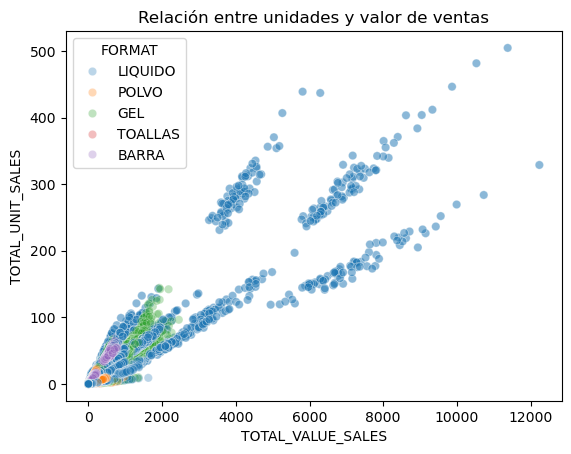

In [159]:
#Que quiero saber: Busco alguna relacion entre ek valor e las ventas y las unidades vendidas.
#Me parece que es la combinacion que mas podria aplicar para este tipo de grafico.
# A pesar de que hay una concentracion de puntos en el cuadrante inferior izquierdo, tambien parece haber un patron en el resto de la grafica.
#El formato LÍQUIDO parece ser el más importante en términos de volumen y valor.
sns.scatterplot(data=df_consolidado, x="TOTAL_VALUE_SALES", y="TOTAL_UNIT_SALES", alpha=0.3, hue = 'FORMAT')
plt.title("Relación entre unidades y valor de ventas")
plt.savefig('Relación_ventas_unidades_formato',dpi=90)

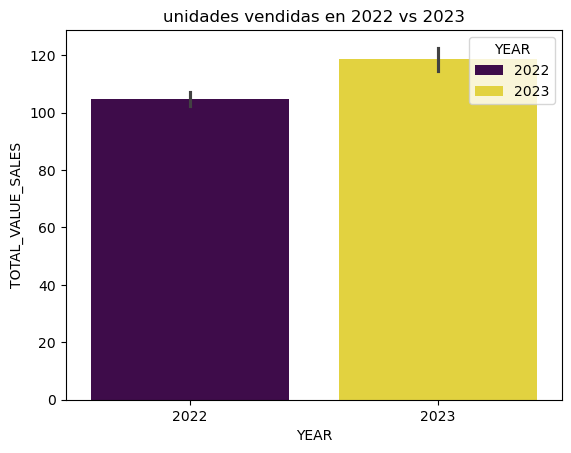

In [163]:
#Que quiero saber: Quiero comparar las ventas del 2022 y rl 2023.
#La grafica muestra que afortunadamente las ventas mejoraron. 
sns.barplot(data=df_consolidado, x="YEAR", y="TOTAL_VALUE_SALES",hue="YEAR",palette="viridis")
plt.title("unidades vendidas en 2022 vs 2023")
plt.savefig('Relación_ventas_2022_2023',dpi=90)